In [11]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt

In [12]:
# custom values
EDGE_LENGTH = 1e-1

RA = 25e-2
HH = 10e-2
DX = 3e-3
V0 = 1
SIGMA = 1e-4
EPSILON = 11

In [13]:
nodes, elements = mt.CircleSegments(middle=[0,0], radius=RA, edge_length=EDGE_LENGTH)

nodes1, elements1 = mt.RectangleSegments([-DX/2, -HH/2], [-DX/2-DX, HH/2], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes1, elements1)

nodes2, elements2 = mt.RectangleSegments([-DX/2-2*DX, -HH/2], [-DX/2-3*DX, HH/2], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes2, elements2)

nodes3, elements3 = mt.RectangleSegments([DX/2, -HH/2], [DX/2+DX, HH/2], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes3, elements3)

nodes4, elements4 = mt.RectangleSegments([DX/2+2*DX, -HH/2], [DX/2+3*DX, HH/2], edge_length=EDGE_LENGTH)
nodes, elements = mt.AddCurves(nodes, elements, nodes4, elements4)

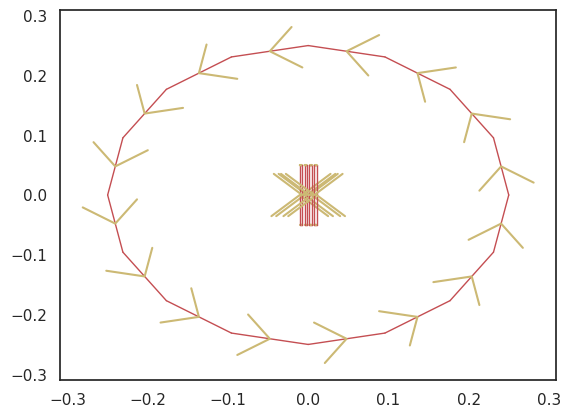

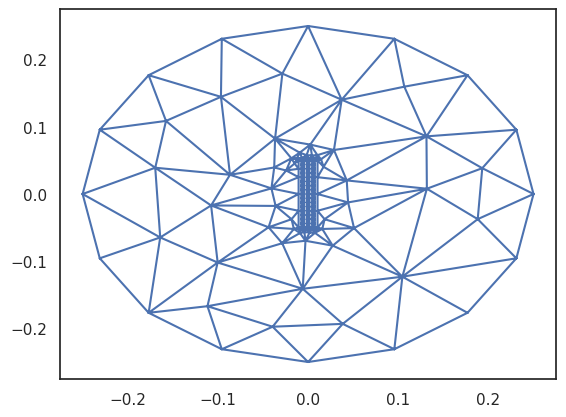

In [14]:
mt.PlotBoundary(nodes, elements, "Segments")
plt.show()

holes=[[-DX, 0], [DX, 0], [-3*DX, 0], [3*DX, 0]]
knots,triangles,BouE,li_BE,bou_elem,CuE,li_CE = mt.DoTriMesh(nodes, elements, EDGE_LENGTH, holes=holes)

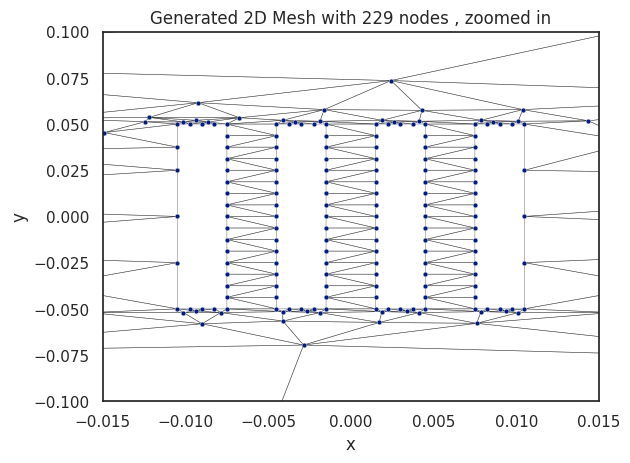

In [15]:
fig, ax = plt.subplots()
ax.set_xlim(-5*DX, 5*DX)
ax.set_ylim(-HH, HH)
myfunc.plot_knots_elements(knots, triangles, ax=ax, title_suffix=", zoomed in")